In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
import h3
import geopandas as gpd
import contextily as cx
from shapely.geometry import Polygon, Point
from geopy.distance import geodesic

In [3]:
# Shared across all three figures in this notebook

FIGURE_DIR = "../output/figures/clustering"
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_figure(filename_stem, directory=FIGURE_DIR):
    """Save the current matplotlib figure as pdf, png and svg."""
    for ext in ["pdf", "png", "svg"]:
        plt.savefig(f"{directory}/{filename_stem}.{ext}", dpi=300, bbox_inches="tight")

cluster_label_map = {
    0: 'Mixed Shift',
    1: 'Day Shift',
    2: 'Weekend Shift',
}
cluster_colors = {0: '#7570b3', 1: '#d95f02', 2:  '#1b9e77'}
default_color = 'gray'

# Work cluster map

In [4]:
# Load the clustered open data and collapse to one row per raster_id
opening_clustered = pd.read_pickle("../output/data/48hr_averages/open_avg48hrs_clustered.pkl")
opening_cluster = opening_clustered[['raster_id', 'work_cluster', 'work_cluster_label']].drop_duplicates()

In [5]:
def h3_to_polygon(h3_id):
    """Convert an H3 cell id to a shapely Polygon (lon, lat order, matching GeoJSON)."""
    boundary = h3.h3_to_geo_boundary(h3_id, geo_json=True)
    return Polygon(boundary)

opening_cluster = opening_cluster.copy()
opening_cluster['geometry'] = opening_cluster['raster_id'].apply(h3_to_polygon)
opening_cluster_gdf = gpd.GeoDataFrame(opening_cluster, geometry='geometry', crs='EPSG:4326')

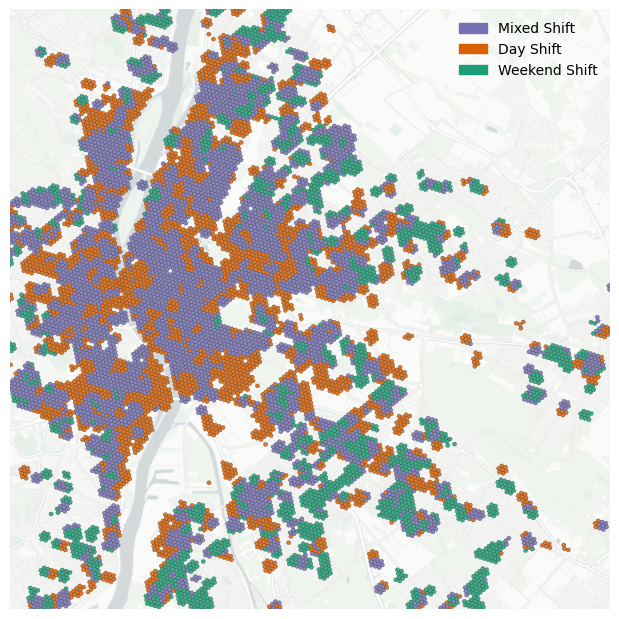

In [6]:
# --- filter to clusters 0, 1, 2, drop NaNs ---
opening_cluster = opening_cluster.copy()
opening_cluster['geometry'] = opening_cluster['raster_id'].apply(h3_to_polygon)
opening_cluster_gdf = gpd.GeoDataFrame(opening_cluster, geometry='geometry', crs='EPSG:4326')

opening_cluster_zoom = opening_cluster_gdf[
    opening_cluster_gdf['work_cluster'].isin([0, 1, 2])
].dropna(subset=['work_cluster', 'geometry']).copy()

opening_cluster_zoom['color'] = opening_cluster_zoom['work_cluster'].map(cluster_colors)

opening_cluster_zoom_3857 = opening_cluster_zoom.to_crs(epsg=3857)

# --- center based on the data's own bounding box ---
minx, miny, maxx, maxy = opening_cluster_zoom_3857.total_bounds
center_x = (minx + maxx) / 2
center_y = (miny + maxy) / 2

fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0, 0, 1, 1], frameon=False, xticks=[], yticks=[])

radius_m = 15000  # adjust if you want to zoom in/out
if radius_m is not None:
    ax.set_xlim(center_x - radius_m, center_x + radius_m)
    ax.set_ylim(center_y - radius_m, center_y + radius_m)
else:
    # auto-fit with a little padding, keeping it square-ish
    pad = 0.05 * max(maxx - minx, maxy - miny)
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)

ax.margins(0)
ax.set_aspect('equal')

opening_cluster_zoom_3857.plot(
    ax=ax,
    color=opening_cluster_zoom_3857['color'],
    ec='#2d2d2d',
    linewidth=0.2,
    alpha=0.85,
)

cx.add_basemap(
    ax,
    crs=opening_cluster_zoom_3857.crs.to_string(),
    source=cx.providers.CartoDB.PositronNoLabels,
    alpha=1,
    attribution=False,
)

ax.axis('off')

legend_handles = [
    mpatches.Patch(color=color, label=cluster_label_map.get(cluster, f'Cluster {cluster}'))
    for cluster, color in cluster_colors.items()
]
ax.legend(handles=legend_handles, loc='upper right', frameon=False, title=False)

save_figure("work_cluster_map_zoomed_v2")
plt.show()

# Work rythm by cluster

In [7]:
# read in data
curfew_path = "../output/data/48hr_averages/curfew_avg48hrs.pkl"
open_path = "../output/data/48hr_averages/open_avg48hrs_clustered.pkl"

curfew = pd.read_pickle(curfew_path)
opening = pd.read_pickle(open_path)

# apply opening's cluster assignment to curfew
cluster_assignment = opening[['raster_id', 'work_cluster']].drop_duplicates()
curfew2 = curfew.merge(cluster_assignment, on='raster_id', how='left')

# use log(loc_work_gaussian)
# directly instead (Gaussian-smoothed work activity, log-transformed but not z-scored)
opening['log_work_gaussian'] = np.log(opening['loc_work_gaussian'])
curfew2['log_work_gaussian'] = np.log(curfew2['loc_work_gaussian'])

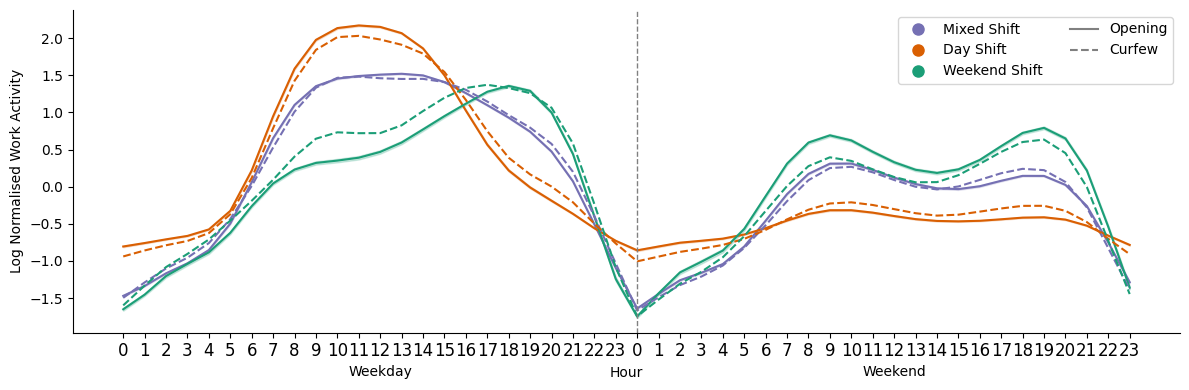

In [8]:
# Compute mean and standard error for each cluster
grouped = opening.groupby(['hour_reordered', 'work_cluster'])['log_work_gauss_norm']
mean_resid_opening = grouped.mean().unstack()
se_resid_opening = grouped.sem().unstack() 

# Compute mean for each cluster
grouped_curfew = curfew2.groupby(['hour_reordered', 'work_cluster'])['log_work_gauss_norm']
mean_curfew = grouped_curfew.mean().unstack()

# Custom labels for legend
cluster_labels = {c: cluster_label_map.get(int(c), f'Cluster {int(c)}') for c in mean_resid_opening.columns}

# Create a single subplot
fig, ax = plt.subplots(figsize=(12, 4))

# Plot work activity with confidence intervals
for cluster in mean_resid_opening.columns:
    color = cluster_colors.get(int(cluster), default_color)
    ax.plot(mean_resid_opening.index, mean_resid_opening[cluster],
            linestyle='-', color=color)

    ax.fill_between(mean_resid_opening.index,
                    mean_resid_opening[cluster] - 1.96 * se_resid_opening[cluster],
                    mean_resid_opening[cluster] + 1.96 * se_resid_opening[cluster],
                    color=color, alpha=0.2)

# Plot work activity
for cluster in mean_curfew.columns:
    color = cluster_colors.get(int(cluster), default_color)
    ax.plot(mean_curfew.index, mean_curfew[cluster], linestyle='--', color=color)

# Adjust xticks to go from 0-23 and then repeat
xticks = list(range(24)) + list(range(24))  # 0-23 twice
plt.xticks(list(range(48)), xticks, fontsize=12)

# Add "Weekday" and "Weekend" labels
y_offset = plt.ylim()[0] - (plt.ylim()[1] - plt.ylim()[0]) * 0.1
plt.text(12, y_offset, 'Weekday', ha='center', va='top', fontsize=10)
plt.text(36, y_offset, 'Weekend', ha='center', va='top', fontsize=10)

ax.set_xlabel('Hour', fontsize=10)
ax.set_ylabel('Log Normalised Work Activity', fontsize=10)
ax.axvline(x=24, color='gray', linestyle='--', linewidth=1)

# Cluster dots
dot_handles = [mlines.Line2D([], [], color=cluster_colors.get(int(c), default_color), marker='o',
                              linestyle='None', markersize=8, label=cluster_labels[c])
               for c in cluster_labels]

# Line styles for opening and curfew
opening_line = mlines.Line2D([], [], color='grey', linestyle='-', label="Opening")
curfew_line = mlines.Line2D([], [], color='grey', linestyle='--', label="Curfew")

legend_handles = dot_handles + [opening_line, curfew_line]
ax.legend(handles=legend_handles, ncol=2, loc='upper right', fontsize=10, frameon=True)

sns.despine()
plt.tight_layout()
save_figure("work_rhythm_by_cluster_open_curfew")
plt.show()

# Scatter plot

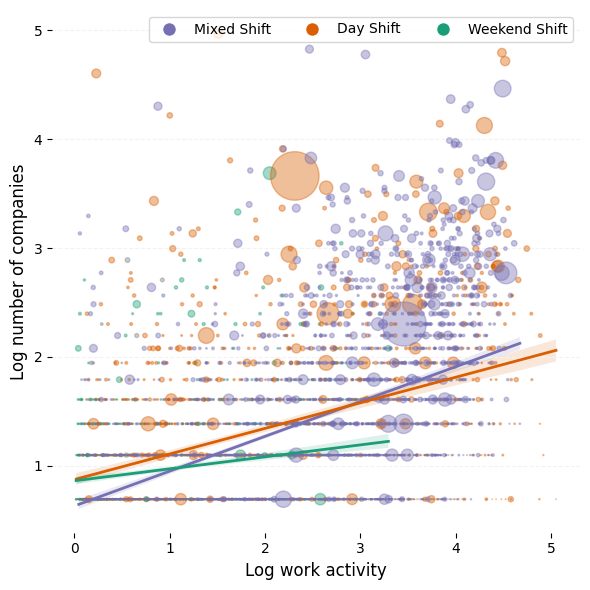

In [ ]:
df = pd.read_pickle('../output/data/merged_analysis_data.pkl')

df['color'] = df['work_cluster'].map(cluster_colors).fillna(default_color)
df['log_nr_comp'] = np.log(df['n_companies'] + 1)
df = df.dropna(subset=['log_work_no0_opening', 'log_nr_comp'])

# Set marker sizes based on the average employee number
df['marker_size'] = df['letszam_besz18'] / 30

# Plot the scatter plot
plt.figure(figsize=(6, 6))

# Plot in order: Unknown, Cluster 2, Cluster 1, Cluster 0
for color in [default_color, cluster_colors[2], cluster_colors[1], cluster_colors[0]]:
    subset = df[df['color'] == color]
    label = 'Unknown' if color == default_color else f'Cluster {subset["work_cluster"].iloc[0]}'
    plt.scatter(subset['log_work_no0_opening'], subset['log_nr_comp'], c=subset['color'], s=subset['marker_size'],
                alpha=0.4, label=label, zorder=2)

# Regression lines with confidence intervals
for cluster, color in cluster_colors.items():
    subset = df[df['work_cluster'] == cluster]
    if not subset.empty:
        sns.regplot(x='log_work_no0_opening', y='log_nr_comp', data=subset, scatter=False,
                    color=color, line_kws={'linewidth': 2}, ci=95)

plt.xlabel('Log work activity', fontsize=12)
plt.ylabel('Log number of companies', fontsize=12)

plt.grid(True, color='#F2F2F2', which='major', linestyle='--', axis='y', zorder=1)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.box(False)

# Custom legend using the shared cluster_label_map (currently placeholders)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                      markersize=10, label=cluster_label_map.get(cluster, f'Cluster {cluster}'))
           for cluster, color in cluster_colors.items()]
plt.legend(handles=handles, fontsize=10, loc=1, ncol=3)

plt.tight_layout()
save_figure("scatter_work_companies")
plt.show()

In [11]:
from scipy.stats import pearsonr

cols = ['log_work_no0_opening', 'log_nr_comp']

# Overall correlation
r_all, p_all = pearsonr(df[cols[0]], df[cols[1]])
r2_all = r_all ** 2
print(f"Overall: r = {r_all:.3f}, R2 = {r2_all:.3f}, p = {p_all:.3g}, n = {len(df)}")

print()

# Correlation by cluster
for cluster in sorted(df['work_cluster'].dropna().unique()):
    subset = df[df['work_cluster'] == cluster][cols].dropna()
    if len(subset) > 1:
        r, p = pearsonr(subset[cols[0]], subset[cols[1]])
        r2 = r ** 2
        label = cluster_label_map.get(cluster, f'Cluster {cluster}')
        print(f"{label} (n={len(subset)}): r = {r:.3f}, R2 = {r2:.3f}, p = {p:.3g}")

Overall: r = 0.475, R2 = 0.226, p = 4.53e-319, n = 5701

Mixed Shift (n=3017): r = 0.493, R2 = 0.243, p = 9.95e-185
Day Shift (n=1450): r = 0.411, R2 = 0.169, p = 2.96e-60
Weekend Shift (n=1202): r = 0.235, R2 = 0.055, p = 1.32e-16
